In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import rankdata
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from decimal import Decimal
import itertools
import csv
import ast
import seaborn as sns
import requests
import re
import ast
import bokeh.plotting as bk

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('loglog.png')
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def pearson(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = pearsonr(data1, data2)
    formatted_p_value = '{:e}'.format(p_value)
    return correlation, formatted_p_value

def get_reactions_for_compound(compound_id):
    response = requests.get(f'https://rest.kegg.jp/link/reaction/{compound_id}')
    lines = response.text.split('\n')
    
    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    return reactions

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX

In [4]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')
x2foAveALL = csv2dict('../data/assets/xgroup2/xgroup2foAveALL.csv')
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2rn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)

x2names = csv2dict('../data/assets/xgroup2/xgroup2names.csv')
x2modules = csv2dict('../data/assets/xgroup2/xgroup2modules.csv')
x2maps = csv2dict('../data/assets/xgroup2/xgroup2maps.csv')

modules = csv2dict('../data/assets/module2name.csv')
module2rn = csv2dict('../data/assets/module2rn.csv')
map2description = csv2dict('../data/assets/map2name.csv')
groupOne2ns = csv2dict('../data/assets/groupOne2ns.csv')


    
print(len(x2foAveNONE))
print(len(x2foAveALL))
print(len(x2ns))
print(len(x2rn))

print(len(x2names))
print(len(x2modules))
print(len(x2maps))
print(len(rn2rules))
print(len(modules))
print(len(module2rn))
print(len(map2description))
print(len(groupOne2ns))

397
397
397
397
237
274
370
12872
479
479
569
37


In [5]:
# DS average
xgroup2ds_a = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv')
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv')
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv')
print(len(xgroup2ds_e))

2230
2230
2230


In [3]:
O2rnsKEGG = get_reactions_for_compound('C00007')

In [4]:
len(O2rnsKEGG), len(set(O2rnsKEGG))  # no duplicates

(1972, 1972)

In [8]:
with open('../data/assets/reaction_iteration_O2_ablation.csv', 'r') as csv_file:
    csv_reader = csv.reader(csv_file)
    
    # Skip the header row
    next(csv_reader)
    
    rns_unreached_wo_O2 = []
    rns_unreached_wo_O2_v = []
    
    for row in csv_reader:
        if '' in row:
            if row[0][-2] != 'v':  # exclude reactions with "v"
                if row[0].startswith('R0') or row[0].startswith('R1'):
                    rns_unreached_wo_O2.append(row[0])
                else:
                    print(row[0])
            else:
                if row[0].endswith('v1'):  # rescue 'v1' because this file does not have "original" w/o version num
                    rns_unreached_wo_O2.append(row[0][:-3])
                else:
                    rns_unreached_wo_O2_v.append(row[0])

RZ_154
RZ_413
QUIN_SYN2
RZ_199
RZ_205
RZ_245
RZ_179
RZ_172
RZ_185
RZ_414
RZ_207
RZ_195
RZ_255
RZ_177
RZ_368
RZ_184
RZ_198
RZ_415
RZ_504
RZ_362
RZ_160
RZ_193
RZ_212
RZ_408
RZ_234
QUIN_SYN1
RZ_396
RZ_153
RZ_412
RZ_166
RZ_189
RZ_121
RZ_155
RZ_358
RZ_183
RZ_409
RZ_242
RZ_214
C11904_syn
RZ_208
RZ_170
C11903_syn
RZ_366
RZ_458
RZ_391
RZ_386
RZ_457


In [9]:
rns_unreached_wo_O2_v  # 179 reactions

['R09503_vX',
 'R08408_v2',
 'R02150_v4',
 'R11713_v2',
 'R07978_v2',
 'R00111_v2',
 'R02173_v3',
 'R03139_v2',
 'R02150_v3',
 'R01803_v2',
 'R04027_v3',
 'R04300_v2',
 'R11713_v3',
 'R02173_v2',
 'R07942_v2',
 'R04674_v2',
 'R11712_v3',
 'R00359_v2',
 'R07977_v2',
 'R06740_v4',
 'R02382_v2',
 'R02613_v3',
 'R05334_v3',
 'R02529_v4',
 'R00557_v2',
 'R06154_v3',
 'R01769_v2',
 'R02197_v2',
 'R03139_v3',
 'R02613_v2',
 'R03871_v2',
 'R02107_v2',
 'R02529_v2',
 'R00275_v4',
 'R06740_v2',
 'R00357_v2',
 'R04300_v3',
 'R06740_v3',
 'R11711_v2',
 'R11711_v3',
 'R07221_v2',
 'R00677_v2',
 'R03220_v2',
 'R02613_v4',
 'R02529_v3',
 'R00275_v2',
 'R02150_v2',
 'R02382_v3',
 'R06154_v4',
 'R01151_v3',
 'R05739_v2',
 'R10517_v2',
 'R02449_v2',
 'R07214_v2',
 'R00729_v2',
 'R00980_v2',
 'R00558_v2',
 'R04027_v2',
 'R11712_v2',
 'R01442_v2',
 'R00069_v2',
 'R00635_v2',
 'R02382_v4',
 'R05334_v4',
 'R04300_v4',
 'R00689_v2',
 'R01709_v2',
 'R03139_v4',
 'R00275_v3',
 'R02173_v4',
 'R06154_v2',
 'R079

In [10]:
# add the extra direct O2 reactions from X5039 (Note from future: none of these show up in our runs!)
for rn in ['R09492', 'R00081', 'R00082', 'R10444']:
    rns_unreached_wo_O2.append(rn)

In [11]:
len(rns_unreached_wo_O2), len(set(rns_unreached_wo_O2))  # has duplicates (forward vs. reverse?)

(1941, 1469)

In [12]:
len(set(rn2rules.keys()) & set(O2rnsKEGG))

1386

In [13]:
len(set(O2rnsKEGG) - set(rn2rules.keys()))

583

In [14]:
O2_direct_rn = set(rns_unreached_wo_O2) & set(O2rnsKEGG)
O2_indirect_rn = set(rns_unreached_wo_O2) - set(O2rnsKEGG)
len(O2_direct_rn), len(O2_indirect_rn), len(set(rns_unreached_wo_O2))

(757, 712, 1469)

In [15]:
# O2-direct reactions on KEGG = 1967
# O2-direct reactions on KEGG AND in rn2rules = 1386

# reactions un-reachable w/o O2 = 1469 (O2-direct + O2-indirect)
# O2-direct reactions on KEGG AND in rns_unreached_wo_O2 = 757
# O2-indirect = 1469 - 757 = 712

In [16]:
x_O2_direct = set()
x_O2_indirect = set()

for x, rns in x2rn.items():
    for rn in rns:
        if rn in O2_direct_rn:
            x_O2_direct.add(x) 
        if rn in O2_indirect_rn:
            x_O2_indirect.add(x)

In [17]:
print(len(x_O2_direct), len(x_O2_indirect), len(x_O2_indirect & x_O2_direct), len(x_O2_indirect | x_O2_direct))

91 107 43 155


In [18]:
# 397 - (88 + 107 + 41 + 154) = 243 ignored O2!!!

# folds that:
(a) emerge in response to O2

(b) learn to use chemistry that O2 made possible

(c) totally ignored O2

## (a) emerge in response to O2

In [19]:
# get the ratio
x2O2rn = {}
for x, rns in x2rn.items():
    fracdict = {'direct':[], 'indirect':[], 'total':[]}
    for rn in rns:
        if rn in O2_direct_rn:
            fracdict['direct'].append(rn)
        if rn in O2_indirect_rn:
            fracdict['indirect'].append(rn)
        if rn[:6] not in fracdict['total']:
            if rn.startswith('R0') or rn.startswith('R1'):
                fracdict['total'].append(rn)
    x2O2rn[x] = fracdict

In [20]:
len(x2O2rn)

397

In [21]:
x2O2rn

{'7553': {'direct': [], 'indirect': [], 'total': ['R04148', 'R10608']},
 '2487': {'direct': [],
  'indirect': ['R01959', 'R11408', 'R00988', 'R04911'],
  'total': ['R01900',
   'R01325',
   'R01324',
   'R00149',
   'R03444',
   'R04371',
   'R01959',
   'R00206',
   'R05338',
   'R05339',
   'R09780',
   'R05677',
   'R11662',
   'R11673',
   'R09325',
   'R09188',
   'R09350',
   'R00199',
   'R00575',
   'R01082',
   'R01397',
   'R01993',
   'R03896',
   'R03898',
   'R03968',
   'R04001',
   'R09720',
   'R10391',
   'R10392',
   'R10393',
   'R10394',
   'R10395',
   'R10396',
   'R11408',
   'R11263',
   'R09326',
   'R11941',
   'R10688',
   'R10687',
   'R11964',
   'R04425',
   'R10951',
   'R00008',
   'R05802',
   'R00350',
   'R00256',
   'R00339',
   'R00988',
   'R01395',
   'R03069',
   'R04911',
   'R08620',
   'R08624',
   'R08628',
   'R08634',
   'R08641',
   'R08645',
   'R10170',
   'R10948',
   'R10949',
   'R11625',
   'R11181',
   'R02628',
   'R07641']},
 '147

In [22]:
print('ALL O2_direct')
print('--------------')
for x, d in x2O2rn.items():
    if len(d['direct']) / len(d['total']) == 1.0:
        print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}, {x2modules.get(x, "NO MODULE")}, {x2maps.get(x, "NO MAPS")}')
        
print('--------------')
print('ALL O2_indirect')
print('--------------')
for x, d in x2O2rn.items():
    if len(d['indirect']) / len(d['total']) == 1.0:
        print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}, {x2modules.get(x, "NO MODULE")}, {x2maps.get(x, "NO MAPS")}')

print('--------------')
print('Mix O2_direct O2_indirect')
print('--------------')
for x, d in x2O2rn.items():
    if len((set(d['direct']) | set(d['indirect']))) / len(d['total']) == 1.0:
        if len(d['direct']) != 0 and len(d['indirect']) != 0:
            print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}, {x2modules.get(x, "NO MODULE")}, {x2maps.get(x, "NO MAPS")}')

ALL O2_direct
--------------
603, STAT-like, fo=351.988, 4315.0, RnNum=3, {'M00174', 'M00804', 'M00528'}, {'map01200', 'map00910', 'map00680'}
6174, NO X NAME, fo=324.683, 4314.0, RnNum=4, NO MODULE, NO MAPS
557, NO X NAME, fo=315.382, 4315.0, RnNum=10, NO MODULE, {'map00362', 'map00624', 'map00627'}
228, NO X NAME, fo=350.988, 4315.0, RnNum=5, NO MODULE, NO MAPS
3115, GP2-like, fo=336.755, 4315.0, RnNum=2, {'M00878'}, {'map00360'}
241, Type III secretory system chaperone-like, fo=336.876, 4315.0, RnNum=2, NO MODULE, {'map00860'}
4160, NO X NAME, fo=337.039, 4315.0, RnNum=2, {'M00622'}, {'map00760'}
262, NO X NAME, fo=306.303, 4315.0, RnNum=21, NO MODULE, {'map00220', 'map00330'}
3752, NO X NAME, fo=336.667, 4315.0, RnNum=2, NO MODULE, NO MAPS
3249, NO X NAME, fo=311.779, 4315.0, RnNum=9, NO MODULE, {'map00220', 'map00330'}
--------------
ALL O2_indirect
--------------
3994, NO X NAME, fo=359.026, 4314.0, RnNum=1, NO MODULE, {'map00440'}
3456, NO X NAME, fo=366.434, 4315.0, RnNum=4, {'

In [23]:
print('ALL O2_direct')
print('--------------')
for mo in {'M00804', 'M00174', 'M00528', 'M00878', 'M00622'}:
    print(mo, modules[mo])
for mp in {'map01200', 'map00680', 'map00910', 'map00362', 'map00627', 'map00624', 'map00360', 'map00860', 'map00760', 'map00220', 'map00330'}:
    print(mp, map2description[mp])

print('--------------')
print('ALL O2_indirect')
print('--------------')
for mo in {'M00146', 'M00143', 'M00142', 'M00144', 'M00147', 'M00145'}:
    print(mo, modules[mo])
for mp in {'map00440', 'map00190'}:
    print(mp, map2description[mp])

print('--------------')
print('Mix O2_direct O2_indirect')
print('--------------')
for mo in {'M00868', 'M00121'}:
    print(mo, modules[mo])
for mp in {'map00340', 'map00350', 'map01240', 'map00860'}:
    print(mp, map2description[mp])

ALL O2_direct
--------------
M00622 Nicotinate degradation, nicotinate => fumarate
M00528 Nitrification, ammonia => nitrite
M00174 Methane oxidation, methanotroph, methane => formaldehyde
M00878 Phenylacetate degradation, phenylaxetate => acetyl-CoA/succinyl-CoA
M00804 Complete nitrification, comammox, ammonia => nitrite => nitrate
map00330 Arginine and proline metabolism
map00627 Aminobenzoate degradation
map00910 Nitrogen metabolism
map00220 Arginine biosynthesis
map00680 Methane metabolism
map00360 Phenylalanine metabolism
map00760 Nicotinate and nicotinamide metabolism
map00362 Benzoate degradation
map00624 Polycyclic aromatic hydrocarbon degradation
map00860 Porphyrin metabolism
map01200 Carbon metabolism
--------------
ALL O2_indirect
--------------
M00147 NADH dehydrogenase (ubiquinone) 1 beta subcomplex
M00146 NADH dehydrogenase (ubiquinone) 1 alpha subcomplex
M00143 NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria
M00142 NADH:ubiquinone oxidoredu

## (b) learn to use chemistry that O2 made possible

In [24]:
# plot fo vs. O2Frac
x2O2rnFrac = {}
for x, d in x2O2rn.items():
    x2O2rnFrac[x] = len((set(d['direct']) | set(d['indirect']))) / len(d['total'])

In [25]:
len(x2O2rnFrac)

397

In [26]:
x2O2rnFrac

{'7553': 0.0,
 '2487': 0.0625,
 '147': 0.0,
 '2011': 0.018518518518518517,
 '4048': 0.3333333333333333,
 '136': 0.23529411764705882,
 '2493': 0.0,
 '4004': 0.0,
 '217': 0.4583333333333333,
 '210': 0.16666666666666666,
 '911': 0.0,
 '3847': 0.0,
 '133': 0.0,
 '313': 0.0,
 '881': 0.5,
 '7514': 0.34375,
 '131': 0.047619047619047616,
 '7550': 0.0,
 '3997': 0.0,
 '603': 1.0,
 '4335': 0.2,
 '300': 0.0,
 '268': 0.17647058823529413,
 '231': 0.38461538461538464,
 '302': 0.25,
 '2012': 0.7142857142857143,
 '2006': 0.0196078431372549,
 '323': 0.15178571428571427,
 '7558': 0.0,
 '275': 0.0,
 '69': 0.0,
 '139': 0.0,
 '1': 0.21794871794871795,
 '6': 0.25,
 '708': 0.0,
 '257': 0.6363636363636364,
 '7540': 0.0,
 '3740': 0.2222222222222222,
 '331': 0.24390243902439024,
 '7568': 0.0,
 '246': 0.0,
 '4011': 0.028037383177570093,
 '4022': 0.0,
 '2484': 0.009433962264150943,
 '3994': 1.0,
 '209': 0.25,
 '253': 0.0,
 '7586': 0.0,
 '7549': 0.0,
 '6174': 1.0,
 '4159': 0.5,
 '12': 0.09774436090225563,
 '7589': 

In [27]:
# dict2csv(x2O2rnFrac, 'xgroup2O2rnFrac.csv')

(0.3797072589271002, '4.607019e-15')


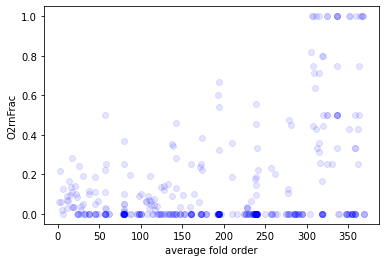

In [28]:
print(pearson(x2foAveNONE, x2O2rnFrac))
scatter(x2foAveNONE, x2O2rnFrac, x_axis='average fold order', y_axis='O2rnFrac')

(0.0737698667845041, '1.423164e-01')


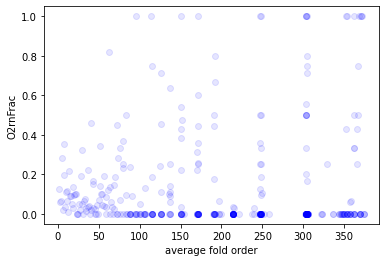

In [29]:
print(pearson(x2foAveALL, x2O2rnFrac))
scatter(x2foAveALL, x2O2rnFrac, x_axis='average fold order', y_axis='O2rnFrac')

In [30]:
print('If 02, ALL O2_direct')
print('--------------')
dir_count = 0
for x, d in x2O2rn.items():
    if len(d['direct']) != 0.0 and len(d['indirect']) == 0.0:
        print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}')
        dir_count += 1
print(f'direct count={dir_count}')
        
print('--------------')
print('If 02, ALL O2_indirect')
print('--------------')
indir_count = 0
for x, d in x2O2rn.items():
    if len(d['indirect']) != 0.0 and len(d['direct']) == 0.0:
        print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}')
        indir_count += 1
print(f'indirect count={indir_count}')

print('--------------')
print('If 02, Mix O2_direct O2_indirect')
print('--------------')
both_count = 0
for x, d in x2O2rn.items():
    if len(d['indirect']) != 0.0 and len(d['direct']) != 0.0:  # both indirect and direct
        if len(d['direct']) != 0 and len(d['total']) != 1.0:
            print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}')
            both_count += 1
print(f'both count={both_count}')

If 02, ALL O2_direct
--------------
4048, NO X NAME, fo=358.458, 4315.0, RnNum=5
881, Mog1p/PsbP-like, fo=336.554, 4315.0, RnNum=3
7514, NO X NAME, fo=138.405, 4304.0, RnNum=194
131, PDEase-like, fo=112.371, 4315.0, RnNum=70
603, STAT-like, fo=351.988, 4315.0, RnNum=3
302, Reverse ferredoxin, fo=80.181, 4314.0, RnNum=8
2012, NO X NAME, fo=309.303, 4301.0, RnNum=24
6, NO X NAME, fo=324.768, 4314.0, RnNum=11
257, NO X NAME, fo=310.303, 4292.0, RnNum=22
331, TBP-like, fo=25.22, 4301.0, RnNum=157
2484, Ribonuclease H-like, fo=79.852, 4152.0, RnNum=218
209, NO X NAME, fo=160.348, 4310.0, RnNum=18
6174, NO X NAME, fo=324.683, 4314.0, RnNum=4
4159, NO X NAME, fo=324.759, 4314.0, RnNum=6
12, Glycosyl hydrolase domain-like, fo=14.482, 4287.0, RnNum=268
557, NO X NAME, fo=315.382, 4315.0, RnNum=10
3156, Cupredoxin-like, fo=281.274, 4311.0, RnNum=44
150, Ferritin/Heme oxygenase/4-helical cytokines, fo=143.082, 4300.0, RnNum=109
230, T-fold, fo=124.62, 4076.0, RnNum=33
5039, NO X NAME, fo=319.135,

## (c) totally ignored O2 => 243 folds

In [31]:
ignored_O2 = set(x2O2rn.keys()) - (x_O2_indirect | x_O2_direct)
for x in ignored_O2:
    print(f'{x}, {x2names.get(x, "NO X NAME")}, fo={x2foAveNONE[x]}, {x2ns[x]}, RnNum={len(x2rn[x])}')
    if x2modules.get(x, "NO MODULE") != "NO MODULE":
        for mo in x2modules.get(x, "NO MODULE"):
            print(mo, modules[mo])
    else:
        print("NO MODULE")
    print('–––––––––––––––––––––––––––––––––––––––––––––––––––')

868, NO X NAME, fo=139.531, 4315.0, RnNum=12
NO MODULE
–––––––––––––––––––––––––––––––––––––––––––––––––––
377, Glucocorticoid receptor-like, fo=194.139, 4315.0, RnNum=21
NO MODULE
–––––––––––––––––––––––––––––––––––––––––––––––––––
239, Ribosomal protein L25-like, fo=131.792, 4313.0, RnNum=18
M00026 Histidine biosynthesis, PRPP => histidine
–––––––––––––––––––––––––––––––––––––––––––––––––––
133, DH domain-like, fo=152.763, 4315.0, RnNum=6
M00377 Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
M00141 C1-unit interconversion, eukaryotes
M00045 Histidine degradation, histidine => N-formiminoglutamate => glutamate
M00140 C1-unit interconversion, prokaryotes
–––––––––––––––––––––––––––––––––––––––––––––––––––
3374, NO X NAME, fo=230.093, 4315.0, RnNum=2
NO MODULE
–––––––––––––––––––––––––––––––––––––––––––––––––––
7522, NO X NAME, fo=133.925, 4309.0, RnNum=68
M00620 Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate
M00004 Pentose phosphate pathway (Pentose phosphate cyc

M00841 Tetrahydrofolate biosynthesis, mediated by PTPS, GTP => THF
–––––––––––––––––––––––––––––––––––––––––––––––––––
4036, NO X NAME, fo=368.951, 4315.0, RnNum=8
NO MODULE
–––––––––––––––––––––––––––––––––––––––––––––––––––
525, NO X NAME, fo=237.833, 4315.0, RnNum=2
NO MODULE
–––––––––––––––––––––––––––––––––––––––––––––––––––
3117, NO X NAME, fo=193.835, 4315.0, RnNum=2
M00028 Ornithine biosynthesis, glutamate => ornithine
M00845 Arginine biosynthesis, glutamate => acetylcitrulline => arginine
–––––––––––––––––––––––––––––––––––––––––––––––––––
590, NO X NAME, fo=223.947, 4313.0, RnNum=11
M00344 Formaldehyde assimilation, xylulose monophosphate pathway
–––––––––––––––––––––––––––––––––––––––––––––––––––
214, NO X NAME, fo=227.043, 4315.0, RnNum=16
M00130 Inositol phosphate metabolism, PI=> PIP2 => Ins(1,4,5)P3 => Ins(1,3,4,5)P4
–––––––––––––––––––––––––––––––––––––––––––––––––––
3292, NO X NAME, fo=194.01, 4315.0, RnNum=3
NO MODULE
––––––––––––––––––––––––––––––––––––––––––––––––––

M00055 N-glycan precursor biosynthesis
M00814 Acarbose biosynthesis, sedoheptulopyranose-7P => acarbose
M00793 dTDP-L-rhamnose biosynthesis
M00014 Glucuronate pathway (uronate pathway)
M00057 Glycosaminoglycan biosynthesis, linkage tetrasaccharide
M00549 Nucleotide sugar biosynthesis, glucose => UDP-glucose
M00114 Ascorbate biosynthesis, plants, fructose-6P => ascorbate
M00070 Glycosphingolipid biosynthesis, lacto-series, LacCer => Lc4Cer
M00909 UDP-N-acetyl-D-glucosamine biosynthesis, prokaryotes, glucose => UDP-GlcNAc
M00815 Validamycin A biosynthesis, sedoheptulopyranose-7P => validamycin A
M00071 Glycosphingolipid biosynthesis, neolacto-series, LacCer => nLc4Cer
M00096 C5 isoprenoid biosynthesis, non-mevalonate pathway
M00066 Lactosylceramide biosynthesis
–––––––––––––––––––––––––––––––––––––––––––––––––––
7604, NO X NAME, fo=239.107, 4315.0, RnNum=6
NO MODULE
–––––––––––––––––––––––––––––––––––––––––––––––––––
296, NO X NAME, fo=173.133, 4314.0, RnNum=20
M00176 Assimilatory sulfat

In [32]:
ignored_O2 & set(groupOne2ns.keys())  # 14 / 37

{'148',
 '184',
 '212',
 '2492',
 '253',
 '297',
 '328',
 '330',
 '3997',
 '4953',
 '7501',
 '7523',
 '7544',
 '875'}

## X3997: chlorophyll + Mg => the last fold in Group I

In [33]:
x2rn['3997']

['R03877']

In [34]:
rn2rules['R03877']

{frozenset({'109', '148', '2004', '2007', '3997'})}

In [35]:
print(f"{xgroup2ds_a['3997']}, {xgroup2ds_b['3997']}, {xgroup2ds_e['3997']}")

0.001515541650790627, 0.00688080039970802, 0.25


In [36]:
# get reaction info
for r in x2rn['3997']:

    url = f'https://rest.kegg.jp/get/{r}'
    response = requests.get(url)
    
    if response.status_code == 200:
        # Print the content of the response
        print(response.text)
        print('---------------------------------')
    else:
        print(f"Error: {response.status_code}")

ENTRY       R03877                      Reaction
NAME        magnesium-protoporphyrin IX chelatase
DEFINITION  ATP + Protoporphyrin + Magnesium cation + H2O <=> ADP + Orthophosphate + Magnesium protoporphyrin + 2 H+
EQUATION    C00002 + C02191 + C00305 + C00001 <=> C00008 + C00009 + C03516 + 2 C00080
RCLASS      RC00002  C00002_C00008
            RC01012  C02191_C03516
ENZYME      6.6.1.1
PATHWAY     rn00860  Porphyrin metabolism
            rn01100  Metabolic pathways
            rn01110  Biosynthesis of secondary metabolites
BRITE       Enzymatic reactions [BR:br08201]
             6. Ligase reactions
              6.6  Forming nitrogen-metal bonds
               6.6.1  Forming coordination complexes
                6.6.1.1
                 R03877  ATP + Protoporphyrin + Magnesium cation + H2O <=> ADP + Orthophosphate + Magnesium protoporphyrin + 2 H+
ORTHOLOGY   K03403  magnesium chelatase subunit H [EC:6.6.1.1]
            K03404  magnesium chelatase subunit D [EC:6.6.1.1]
        

In [37]:
x2foAveNONE['3997']

304.303

# old dog new trick vs. new dog old trick

(0.3797072589271002, '4.607019e-15')


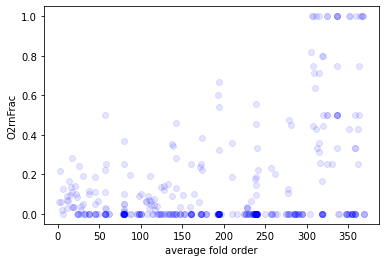

In [38]:
print(pearson(x2foAveNONE, x2O2rnFrac))
scatter(x2foAveNONE, x2O2rnFrac, x_axis='average fold order', y_axis='O2rnFrac')

In [39]:
x2foAveNONE['3997']

304.303

In [40]:
oldDogNewTrick = set()  # 'new trick' = O2 reactions
newDogOldTrick = set()  # 'old trick' = non-O2 reactions

noO2old = set()
noO2new = set()

newO2only = set()

for x in x2O2rnFrac.keys():
    if x2foAveNONE[x] < x2foAveNONE['3997'] and x2O2rnFrac[x] > 0:  # earlier than X3997 & has 02 reactions
        oldDogNewTrick.add(x) 
    if x2foAveNONE[x] > x2foAveNONE['3997'] and 0 < x2O2rnFrac[x] < 1.0: # later than X3997 & has non-02 reactions
        newDogOldTrick.add(x)
    
    if x2foAveNONE[x] < x2foAveNONE['3997'] and x2O2rnFrac[x] == 0: # earlier than X3997 & no O2 at all
        noO2old.add(x)
    if x2foAveNONE[x] > x2foAveNONE['3997'] and x2O2rnFrac[x] == 0: # later than X3997 & no O2 at all
        noO2new.add(x)
    
    if x2foAveNONE[x] > x2foAveNONE['3997'] and x2O2rnFrac[x] == 1.0: # later than X3997 & all O2
        newO2only.add(x)

In [41]:
len(oldDogNewTrick), len(newDogOldTrick)

(104, 34)

In [42]:
len(noO2old), len(noO2new)  # noO2new overlaps with newDogOldTrick

(210, 31)

In [43]:
len(newO2only)

17

In [44]:
set(x2ns.keys()) - (oldDogNewTrick | newDogOldTrick |noO2old | noO2new | newO2only)

{'3997'}

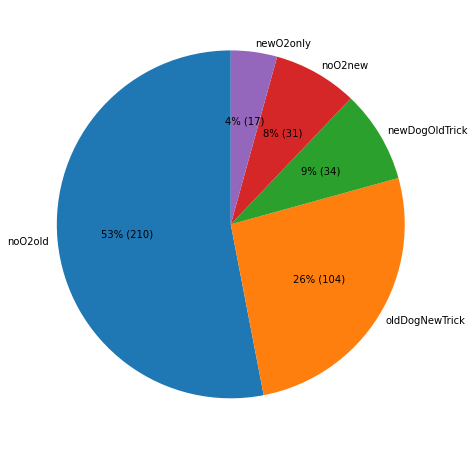

In [45]:
labels = ['noO2old', 'oldDogNewTrick', 'newDogOldTrick', 'noO2new', 'newO2only']
values = [210, 104, 34, 31, 17]

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
plt.show()
# plt.savefig('pie_arch_highDS.png')
plt.show()

In [46]:
rn2module = csv2dict('../data/assets/rn2module.csv')

# new folds that DONT use Oxygen

In [47]:
for x in noO2new:
    for rn in x2rn[x]:
        if rn[-2] != 'v':  # ignore v1 v2 etc.
            print(f"X{x} {rn} #rules={len(rn2rules[rn])}, {rn2module.get(rn, 'NO MODULE')}")

X3993 R10204 #rules=1, NO MODULE
X3500 R00806 #rules=1, NO MODULE
X3500 R06036 #rules=1, NO MODULE
X3500 R07256 #rules=1, NO MODULE
X3500 R08676 #rules=1, NO MODULE
X3294 R04952 #rules=4, ['M00083']
X3294 R04536 #rules=4, ['M00083']
X3294 R04534 #rules=4, ['M00083']
X3294 R04533 #rules=4, ['M00083']
X3294 R04355 #rules=4, ['M00082', 'M00083']
X3294 R04543 #rules=4, ['M00083']
X3294 R04566 #rules=4, ['M00083']
X3294 R04964 #rules=4, ['M00083']
X3294 R04963 #rules=4, ['M00083']
X3294 R04968 #rules=4, ['M00083']
X3294 R04960 #rules=4, ['M00083']
X3294 R04953 #rules=4, ['M00083']
X3294 R04957 #rules=4, ['M00083']
X3294 R04726 #rules=4, ['M00083']
X3294 R05190 #rules=1, NO MODULE
X132 R04952 #rules=4, ['M00083']
X132 R04536 #rules=4, ['M00083']
X132 R04534 #rules=4, ['M00083']
X132 R04533 #rules=4, ['M00083']
X132 R04355 #rules=4, ['M00082', 'M00083']
X132 R04543 #rules=4, ['M00083']
X132 R04566 #rules=4, ['M00083']
X132 R04964 #rules=4, ['M00083']
X132 R04963 #rules=4, ['M00083']
X132 R049

In [48]:
rn2rules['R00005']

{frozenset({'7552', '810'}),
 frozenset({'10', '2003', '206', '306', '325', '75', '7552', '810'})}

In [49]:
x2foAveNONE['810'], x2foAveNONE['7552']

(80.208, 79.995)

In [50]:
print('X(806, 169)')
print('M00001', modules['M00001'])
print('M00002', modules['M00002'])
print('M00309', modules['M00309'])
print('M00541', modules['M00541'])
print("-------------------")

print('X3321, 3322, (132, 3294)')
print('M00082', modules['M00082'])
print('M00083', modules['M00083'])
print("-------------------")

print('X4971, 4223, 7595')
print('M00377', modules['M00377'])
print('M00357', modules['M00357'])
print('M00422', modules['M00422'])
print("-------------------")

print('X869')
print('M00567', modules['M00567'])

X(806, 169)
M00001 Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate
M00002 Glycolysis, core module involving three-carbon compounds
M00309 Non-phosphorylative Entner-Doudoroff pathway, gluconate/galactonate => glycerate
M00541 Benzoyl-CoA degradation, benzoyl-CoA => 3-hydroxypimeloyl-CoA
-------------------
X3321, 3322, (132, 3294)
M00082 Fatty acid biosynthesis, initiation
M00083 Fatty acid biosynthesis, elongation
-------------------
X4971, 4223, 7595
M00377 Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
M00357 Methanogenesis, acetate => methane
M00422 Acetyl-CoA pathway, CO2 => acetyl-CoA
-------------------
X869
M00567 Methanogenesis, CO2 => methane


## X806, 169

In [51]:
print(x2rn['806'])
print(x2rn['169'])
# identical

['R07159', 'R08571', 'R10961', 'R07158', 'R08571_v1', 'R07158_v1', 'R07159_v1']
['R07159', 'R08571', 'R10961', 'R07158', 'R08571_v1', 'R07158_v1', 'R07159_v1']


In [52]:
set(x2rn['806']) & set(module2rn['M00001'])  # single reaction! 'R07159'

{'R07159'}

In [53]:
set(x2rn['806']) & set(module2rn['M00002'])  # single reaction! 'R07159'

{'R07159'}

In [54]:
set(x2rn['806']) & set(module2rn['M00309'])

{'R08571'}

In [55]:
set(x2rn['806']) & set(module2rn['M00541'])

{'R10961'}

## fatty acid synth X3321, X3322, (X132, X3294)

### initiation ['M00082']

In [56]:
set(x2rn['3321']) & set(module2rn['M00082'])

{'R01624', 'R01626', 'R04355'}

In [57]:
set(x2rn['3322']) & set(module2rn['M00082'])

{'R01624', 'R01626'}

In [58]:
set(x2rn['3294']) & set(module2rn['M00082'])

{'R04355'}

In [59]:
set(x2rn['132']) & set(module2rn['M00082'])

{'R04355'}

### elongation ['M00083']

In [60]:
set(x2rn['3321']) & set(module2rn['M00083'])

{'R04355',
 'R04428',
 'R04429',
 'R04430',
 'R04533',
 'R04534',
 'R04535',
 'R04536',
 'R04537',
 'R04543',
 'R04544',
 'R04566',
 'R04568',
 'R04724',
 'R04725',
 'R04726',
 'R04952',
 'R04953',
 'R04954',
 'R04955',
 'R04956',
 'R04957',
 'R04958',
 'R04959',
 'R04960',
 'R04961',
 'R04962',
 'R04963',
 'R04964',
 'R04965',
 'R04966',
 'R04967',
 'R04968',
 'R04969',
 'R04970'}

In [61]:
set(x2rn['3322']) & set(module2rn['M00083'])

{'R04428',
 'R04430',
 'R04535',
 'R04537',
 'R04544',
 'R04568',
 'R04725',
 'R04954',
 'R04956',
 'R04959',
 'R04962',
 'R04965',
 'R04967',
 'R04970'}

In [62]:
set(x2rn['3294']) & set(module2rn['M00083']) == set(x2rn['132']) & set(module2rn['M00083'])

True

In [63]:
set(x2rn['3294']) & set(module2rn['M00083'])

{'R04355',
 'R04533',
 'R04534',
 'R04536',
 'R04543',
 'R04566',
 'R04726',
 'R04952',
 'R04953',
 'R04957',
 'R04960',
 'R04963',
 'R04964',
 'R04968'}

## Acetyl-CoA: X(4971, 4223), 7595

In [64]:
print(modules['M00377'])
print(modules['M00357'])
print(modules['M00422'])

Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
Methanogenesis, acetate => methane
Acetyl-CoA pathway, CO2 => acetyl-CoA


In [65]:
x2rn['7595']

['R09096', 'R10219', 'R10243', 'R10385', 'R10243_v1', 'R10385_v1']

In [66]:
set(x2rn['7595']) & set(module2rn['M00377'])

{'R10243'}

In [67]:
set(x2rn['7595']) & set(module2rn['M00357'])

{'R09096'}

In [68]:
set(x2rn['7595']) & set(module2rn['M00422'])

{'R09096', 'R10219'}

In [69]:
x2rn['4971'] == x2rn['4223']

True

In [70]:
x2rn['4971']

['R08433',
 'R09096',
 'R10219',
 'R10243',
 'R09317',
 'R09317_v1',
 'R10243_v1',
 'R08433_v1']

In [71]:
set(x2rn['4971']) & set(module2rn['M00377'])

{'R08433', 'R10243'}

In [72]:
set(x2rn['4971']) & set(module2rn['M00357'])

{'R09096'}

In [73]:
set(x2rn['4971']) & set(module2rn['M00422'])

{'R09096', 'R10219'}

In [74]:
# {'R08433', 'R09096', 'R10219', 'R10243'}

## methanogenesis: X869

In [75]:
print(modules['M00567'])

Methanogenesis, CO2 => methane


In [76]:
x2rn['869']

['R03464']

In [77]:
rn2rules['R03464']

{frozenset({'869'})}

In [78]:
x2foAveNONE['869']

318.946

In [79]:
# C04330 + C00001 <=> C01274 + C00080

## direct O2 reactions!! : X5039
this guy should be added to our direct-02 list

In [80]:
print('M00529', modules['M00529'])
print('M00416', modules['M00416'])  
print('M00154', modules['M00154']) 
print('M00155', modules['M00155']) 
print('M00156', modules['M00156']) 

M00529 Denitrification, nitrate => nitrogen
M00416 Cytochrome aa3-600 menaquinol oxidase
M00154 Cytochrome c oxidase
M00155 Cytochrome c oxidase, prokaryotes
M00156 Cytochrome c oxidase, cbb3-type


In [81]:
x2rn['5039']

['R00294', 'R09492', 'R00081', 'R00082', 'R10444', 'R00294_v1']

In [82]:
for rn in x2rn['5039']:
    print(rn, rn in rns_unreached_wo_O2, rn in O2rnsKEGG, rn in rn2rules.keys())

R00294 False False True
R09492 True True True
R00081 True True True
R00082 True True True
R10444 True True True
R00294_v1 False False True


In [83]:
for rn in x2rn['5039']:
    print(rn, rn2rules[rn])

R00294 {frozenset({'107'}), frozenset({'148', '2004'}), frozenset({'5039'}), frozenset({'5038', '107'})}
R09492 {frozenset({'5039'}), frozenset({'5038'}), frozenset({'5040', '3156'})}
R00081 {frozenset({'5039', '5040', '5038', '107', '3156'})}
R00082 {frozenset({'5039', '5038', '107'}), frozenset({'5039', '5040', '5038', '107', '3156'}), frozenset({'5038'})}
R10444 {frozenset({'3156', '5038'}), frozenset({'5039', '5038'})}
R00294_v1 {frozenset({'107'}), frozenset({'148', '2004'}), frozenset({'5039'}), frozenset({'5038', '107'})}


In [84]:
## let's check others:
gap = (set(O2rnsKEGG) & set(rn2rules.keys())) - set(rns_unreached_wo_O2)
print(gap)

{'R10101', 'R06679', 'R04102', 'R09151', 'R11197', 'R03712', 'R08275', 'R09313', 'R10445', 'R09577', 'R07098', 'R11807', 'R05411', 'R04366', 'R06337', 'R06291', 'R05442', 'R12321', 'R10522', 'R03615', 'R05413', 'R00083', 'R08965', 'R07207', 'R05463', 'R09934', 'R10672', 'R12230', 'R11163', 'R11993', 'R01593', 'R12253', 'R10056', 'R12270', 'R02503', 'R03262', 'R03812', 'R06691', 'R11811', 'R07704', 'R09198', 'R11640', 'R11054', 'R03807', 'R07471', 'R11000', 'R08274', 'R07572', 'R09817', 'R03698', 'R09867', 'R10076', 'R08841', 'R09334', 'R09567', 'R08392', 'R05155', 'R04523', 'R12317', 'R04597', 'R12016', 'R02356', 'R05406', 'R05266', 'R08100', 'R01306', 'R07657', 'R08257', 'R07777', 'R07450', 'R10123', 'R11489', 'R03087', 'R08053', 'R07454', 'R10110', 'R11813', 'R08020', 'R10316', 'R09416', 'R03842', 'R12018', 'R10321', 'R07085', 'R03202', 'R10999', 'R06689', 'R08101', 'R00041', 'R08666', 'R04826', 'R05422', 'R05434', 'R08055', 'R06688', 'R10853', 'R10857', 'R07360', 'R04400', 'R06538',

# old dog new trick vs. noO2old

(0.3797072589271002, '4.607019e-15')


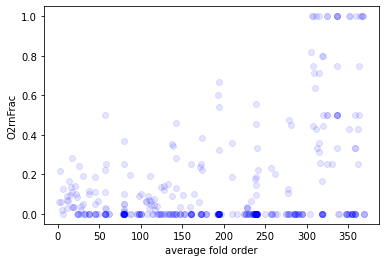

In [85]:
print(pearson(x2foAveNONE, x2O2rnFrac))
scatter(x2foAveNONE, x2O2rnFrac, x_axis='average fold order', y_axis='O2rnFrac')

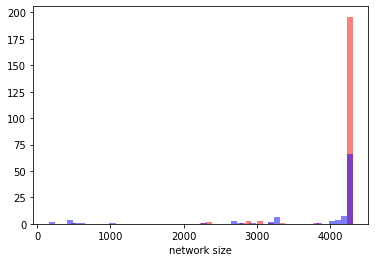

In [86]:
# ns

odnt2ns = []
for x in oldDogNewTrick:
    odnt2ns.append(x2ns[x])

noO2old2ns = []
for x in noO2old:
    noO2old2ns.append(x2ns[x])

plt.hist(noO2old2ns, bins=50, color='r', alpha=0.5)
plt.hist(odnt2ns, bins=50, color='b', alpha=0.5)
plt.xlabel('network size')

plt.show()

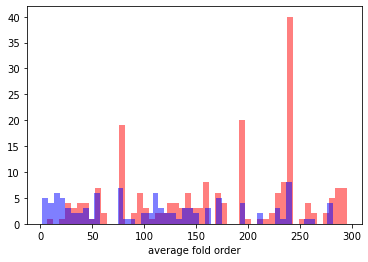

In [87]:
# fo

odnt2fo = []
for x in oldDogNewTrick:
    odnt2fo.append(x2foAveNONE[x])

noO2old2fo = []
for x in noO2old:
    noO2old2fo.append(x2foAveNONE[x])

plt.hist(noO2old2fo, bins=50, color='r', alpha=0.5)
plt.hist(odnt2fo, bins=50, color='b', alpha=0.5)
plt.xlabel('average fold order')
plt.show()

In [88]:
x2ds_ab = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv')

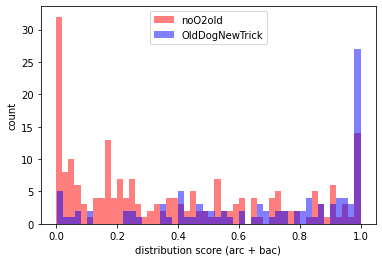

In [89]:
# ds

odnt2ds = {}
for x in oldDogNewTrick:
    odnt2ds[x] = x2ds_ab[x]

noO2old2ds = {}
for x in noO2old:
    noO2old2ds[x] = x2ds_ab[x]

plt.hist(noO2old2ds.values(), bins=50, color='r', alpha=0.5)
plt.hist(odnt2ds.values(), bins=50, color='b', alpha=0.5)
plt.legend(labels=['noO2old', 'OldDogNewTrick'], loc='upper center')
plt.xlabel('distribution score (arc + bac)')
plt.ylabel('count')
# plt.savefig('1.png')
plt.show()

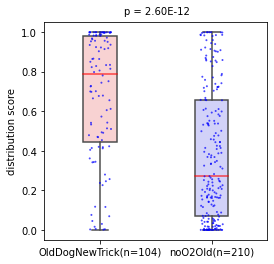

In [90]:
# boxplot

fig, ax = plt.subplots(figsize=(4, 4))
box_colors = ['red', 'blue']

data1 = list(odnt2ds.values())
data2 = list(noO2old2ds.values())

# Use seaborn boxplot
boxplot = sns.boxplot(data=[data1, data2], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[data1, data2], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(data1, data2)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('distribution score')
ax.set_xticklabels(['OldDogNewTrick(n=104)', 'noO2Old(n=210)'])

# plt.savefig('1box.png', bbox_inches='tight')
plt.show()

In [91]:
# what are the low DS odnt folds?
for x, ds in odnt2ds.items():
    if ds < 0.1:
        print(x, ds)

3687 0.0015352005762123723
503 0.03040925450066743
149 0.06917729778291132
3264 0.005150434684200176
4194 0.003532955005152141
6058 0.015967066780632245
108 0.0758786884567644
315 0.04517039081948685
371 0.002464346420342572


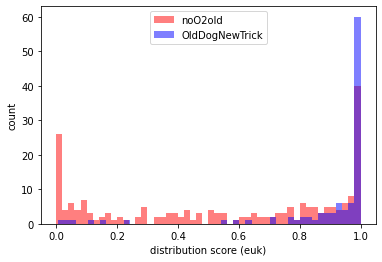

In [92]:
# ds (eukaryotes)

odnt2ds_e = []
for x in oldDogNewTrick:
    odnt2ds_e.append(xgroup2ds_e[x])

noO2old2ds_e = []
for x in noO2old:
    noO2old2ds_e.append(xgroup2ds_e[x])

plt.hist(noO2old2ds_e, bins=50, color='r', alpha=0.5)
plt.hist(odnt2ds_e, bins=50, color='b', alpha=0.5)
plt.xlabel('distribution score (euk)')
plt.legend(labels=['noO2old', 'OldDogNewTrick'], loc='upper center')
plt.ylabel('count')
# plt.savefig('2.png')
plt.show()

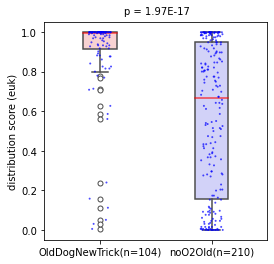

In [93]:
# boxplot

fig, ax = plt.subplots(figsize=(4, 4))

box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[odnt2ds_e, noO2old2ds_e], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[odnt2ds_e, noO2old2ds_e], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(odnt2ds_e, noO2old2ds_e)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('distribution score (euk)')
ax.set_xticklabels(['OldDogNewTrick(n=104)', 'noO2Old(n=210)'])

# plt.savefig('2box.png', bbox_inches='tight')
plt.show()

In [94]:
x2O2rn['206']

{'direct': [],
 'indirect': ['R10091',
  'R10090',
  'R08480',
  'R11933',
  'R03295',
  'R02903',
  'R01889',
  'R01888'],
 'total': ['R01771',
  'R00149',
  'R09775',
  'R04143',
  'R01021',
  'R01468',
  'R03469',
  'R03433',
  'R03361',
  'R03478',
  'R03429',
  'R05202',
  'R00206',
  'R10929',
  'R11064',
  'R11245',
  'R12293',
  'R12311',
  'R12312',
  'R12308',
  'R12354',
  'R12353',
  'R10091',
  'R10090',
  'R10902',
  'R07404',
  'R06975',
  'R00344',
  'R00352',
  'R00405',
  'R00432',
  'R00497',
  'R00575',
  'R00727',
  'R00742',
  'R00894',
  'R01256',
  'R01322',
  'R01397',
  'R01859',
  'R01993',
  'R04138',
  'R04144',
  'R04208',
  'R04209',
  'R04325',
  'R04591',
  'R05799',
  'R12596',
  'R12599',
  'R03479',
  'R10679',
  'R11302',
  'R09767',
  'R09401',
  'R05803',
  'R03378',
  'R08480',
  'R01150',
  'R11933',
  'R11400',
  'R08968',
  'R06974',
  'R10693',
  'R10823',
  'R05800',
  'R00912',
  'R09594',
  'R00910',
  'R03295',
  'R08906',
  'R11024',
  '

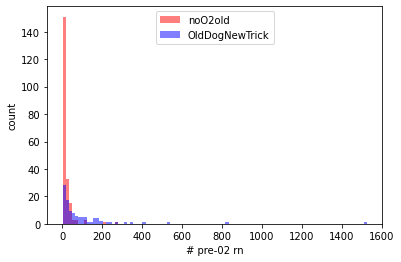

In [95]:
# numrn
# odnt2numrn = []
# for x in oldDogNewTrick:
#     odnt2numrn.append(len(x2rn[x]))

noO2old2numrn = []
for x in noO2old:
    noO2old2numrn.append(len(x2rn[x]))
    
# use only non-O2 reactions
odnt2numrn = []
for x in oldDogNewTrick:
    odnt2numrn.append(len(x2O2rn[x]['total']) - len(x2O2rn[x]['direct']) - len(x2O2rn[x]['indirect']))
    
# define bins
min_val = min(min(noO2old2numrn), min(odnt2numrn))
max_val = max(max(noO2old2numrn), max(odnt2numrn))
bins = np.linspace(min_val, max_val, 100)
    
    
plt.hist(noO2old2numrn, bins=bins, color='r', alpha=0.5)
plt.hist(odnt2numrn, bins=bins, color='b', alpha=0.5)
plt.legend(labels=['noO2old', 'OldDogNewTrick'], loc='upper center')
plt.xlabel('# pre-02 rn')
plt.ylabel('count')
# plt.savefig('3.png')
plt.show()

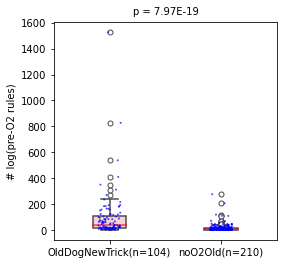

In [96]:
# boxplot 
fig, ax = plt.subplots(figsize=(4, 4))

box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[odnt2numrn, noO2old2numrn], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[odnt2numrn, noO2old2numrn], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(odnt2numrn, noO2old2numrn)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('# log(pre-O2 rules)')
ax.set_xticklabels(['OldDogNewTrick(n=104)', 'noO2Old(n=210)'])

# plt.savefig('3box', bbox_inches='tight')
plt.show()

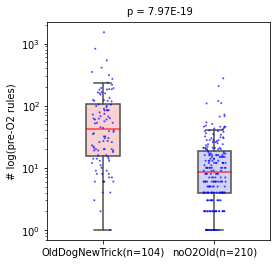

In [97]:
# boxplot LOG
fig, ax = plt.subplots(figsize=(4, 4))


box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[odnt2numrn, noO2old2numrn], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7), showfliers=False)

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[odnt2numrn, noO2old2numrn], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# Set y-axis to log scale
ax.set_yscale('log')

# U-test
statistic, p_value = mannwhitneyu(odnt2numrn, noO2old2numrn)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('# log(pre-O2 rules)')
ax.set_xticklabels(['OldDogNewTrick(n=104)', 'noO2Old(n=210)'])

# plt.savefig('3box', bbox_inches='tight')
plt.show()

In [98]:
x2O2rn['2487']

{'direct': [],
 'indirect': ['R01959', 'R11408', 'R00988', 'R04911'],
 'total': ['R01900',
  'R01325',
  'R01324',
  'R00149',
  'R03444',
  'R04371',
  'R01959',
  'R00206',
  'R05338',
  'R05339',
  'R09780',
  'R05677',
  'R11662',
  'R11673',
  'R09325',
  'R09188',
  'R09350',
  'R00199',
  'R00575',
  'R01082',
  'R01397',
  'R01993',
  'R03896',
  'R03898',
  'R03968',
  'R04001',
  'R09720',
  'R10391',
  'R10392',
  'R10393',
  'R10394',
  'R10395',
  'R10396',
  'R11408',
  'R11263',
  'R09326',
  'R11941',
  'R10688',
  'R10687',
  'R11964',
  'R04425',
  'R10951',
  'R00008',
  'R05802',
  'R00350',
  'R00256',
  'R00339',
  'R00988',
  'R01395',
  'R03069',
  'R04911',
  'R08620',
  'R08624',
  'R08628',
  'R08634',
  'R08641',
  'R08645',
  'R10170',
  'R10948',
  'R10949',
  'R11625',
  'R11181',
  'R02628',
  'R07641']}

## oldDogNewTrick - Which ones are especially "smart"?

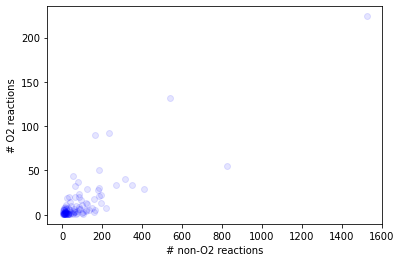

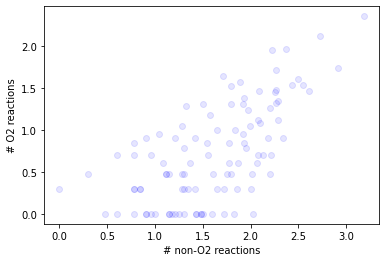

In [99]:
x2preO2rn = {}
for x in oldDogNewTrick:
    x2preO2rn[x] = (len(x2O2rn[x]['total']) - len(x2O2rn[x]['direct']) - len(x2O2rn[x]['indirect']))

x2postO2rn = {}
for x in oldDogNewTrick:
    x2postO2rn[x] = (len(x2O2rn[x]['direct']) + len(x2O2rn[x]['indirect']))

scatter(x2preO2rn, x2postO2rn, y_axis='# O2 reactions', x_axis='# non-O2 reactions')
loglog(x2preO2rn, x2postO2rn, y_axis='# O2 reactions', x_axis='# non-O2 reactions')

In [100]:
odnt2ratio = {}
for x in oldDogNewTrick:
    odnt2ratio[x] = (x2postO2rn[x] / x2preO2rn[x])

In [101]:
odnt2ratio

{'7561': 1.0,
 '7574': 0.027777777777777776,
 '129': 0.06741573033707865,
 '7524': 0.0967741935483871,
 '7577': 0.16216216216216217,
 '5084': 0.15,
 '247': 0.3333333333333333,
 '4052': 0.14705882352941177,
 '236': 0.03048780487804878,
 '179': 0.9047619047619048,
 '2002': 0.06650544135429262,
 '244': 0.5421686746987951,
 '633': 0.10714285714285714,
 '302': 0.3333333333333333,
 '2005': 0.014925373134328358,
 '2484': 0.009523809523809525,
 '279': 0.037037037037037035,
 '141': 0.03686635944700461,
 '211': 0.5789473684210527,
 '3687': 0.23076923076923078,
 '503': 0.16666666666666666,
 '11': 0.15469613259668508,
 '221': 0.23577235772357724,
 '222': 0.041666666666666664,
 '149': 0.24535315985130113,
 '1001': 0.3,
 '107': 0.17391304347826086,
 '3447': 1.25,
 '7514': 0.5238095238095238,
 '2003': 0.14678899082568808,
 '150': 0.39473684210526316,
 '131': 0.05,
 '206': 0.052980132450331126,
 '7567': 0.125,
 '3740': 0.2857142857142857,
 '209': 0.3333333333333333,
 '604': 0.23076923076923078,
 '103'

In [103]:
x2rn = csv2dict('../data/assets/xgroup2/xgroup2rn.csv')
x2rnNum = {}
for x in x2rn.keys():
    x2rnNum[x] = len(x2rn[x])

In [ ]:
# x2rnNum.pop('2003')
# x2rnNum.pop('2002')

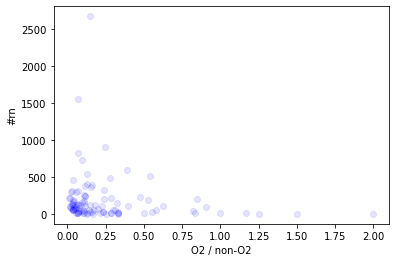

In [104]:
# look at the ratio
scatter(odnt2ratio, x2rnNum, x_axis='O2 / non-O2', y_axis='#rn')

In [105]:
sorted_items = sorted(odnt2ratio.items(), key=lambda x: x[1], reverse=True)
sorted_items[:10]

[('106', 2.0),
 ('6058', 1.5),
 ('3447', 1.25),
 ('5038', 1.1666666666666667),
 ('7561', 1.0),
 ('179', 0.9047619047619048),
 ('217', 0.8461538461538461),
 ('5069', 0.8333333333333334),
 ('3156', 0.8181818181818182),
 ('231', 0.625)]

In [106]:
for tup in sorted_items[:10]:
    x = tup[0]
    print(f"X{x} ratio={round(odnt2ratio[x],3)} fo={x2foAveNONE[x]}, direct:indirect:total={len(x2O2rn[x]['direct'])}:{len(x2O2rn[x]['indirect'])}:{len(x2O2rn[x]['total'])}")
    for mod in x2modules.get(x, 'no module'):
        if mod.startswith('M'):
            print(mod, modules[mod])
        else:
            print('N/A')
            break
    print('--------------')


X106 ratio=2.0 fo=194.167, direct:indirect:total=2:0:3
N/A
--------------
X6058 ratio=1.5 fo=193.677, direct:indirect:total=1:2:5
N/A
--------------
X3447 ratio=1.25 fo=238.763, direct:indirect:total=0:5:9
M00102 Ergocalciferol biosynthesis, squalene 2,3-epoxide => ergosterol/ergocalciferol
M00917 Phytosterol biosynthesis, squalene 2,3-epoxide => campesterol/sitosterol
M00101 Cholesterol biosynthesis, squalene 2,3-epoxide => cholesterol
--------------
X5038 ratio=1.167 fo=193.913, direct:indirect:total=4:3:13
M00154 Cytochrome c oxidase
M00529 Denitrification, nitrate => nitrogen
M00089 Triacylglycerol biosynthesis
M00416 Cytochrome aa3-600 menaquinol oxidase
M00156 Cytochrome c oxidase, cbb3-type
M00155 Cytochrome c oxidase, prokaryotes
M00417 Cytochrome o ubiquinol oxidase
--------------
X7561 ratio=1.0 fo=57.338, direct:indirect:total=0:8:16
M00622 Nicotinate degradation, nicotinate => fumarate
M00835 Pyocyanine biosynthesis, chorismate => pyocyanine
M00939 Pyrimidine degradation, u

## what about architecture?

In [107]:
x2arc = csv2dict('../data/assets/xgroup2/xgroup2architecture.csv')
print(len(x2arc))

2458


In [108]:
keys_to_remove = []
for key in x2arc.keys():
    if key not in x2ns.keys():
        keys_to_remove.append(key)

for key in keys_to_remove:
    x2arc.pop(key)

In [109]:
new = {'beta': ['beta barrels',
 'beta meanders',
 'beta sandwiches',
 'beta duplicates or obligate multimers',
 'beta complex topology'], 'alpha': ['alpha arrays',
 'alpha bundles',
 'alpha duplicates or obligate multimers',
 'alpha superhelices',
 'alpha complex topology'], 'mixed': ['a+b two layers',
 'a+b three layers',
 'a+b four layers',
 'a+b complex topology',
 'a+b duplicates or obligate multimers',
 'a/b barrels',
 'a/b three-layered sandwiches',
 'mixed a+b and a/b'], 'other': ['few secondary structure elements',
 'extended segments']}

In [110]:
alpha = set()
beta = set()
mixed = set()
other = set()

for key, value in x2arc.items():
    if value in new['alpha']:
        alpha.add(key)
    if value in new['beta']:
        beta.add(key) 
    if value in new['mixed']:
        mixed.add(key) 
    if value in new['other']:
        other.add(key) 

print(len(alpha))
print(len(beta))
print(len(mixed))
print(len(other))
print(len(alpha) + len(beta) + len(mixed) + len(other))
print(len(x2arc.keys()))

112
45
215
25
397
397


In [111]:
print(len(oldDogNewTrick & alpha))
print(len(oldDogNewTrick & beta))
print(len(oldDogNewTrick & mixed))
print(len(oldDogNewTrick & other))

28
11
62
3


In [112]:
print(len(noO2old & alpha))
print(len(noO2old & beta))
print(len(noO2old & mixed))
print(len(noO2old & other))

49
23
125
13


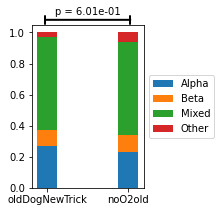

In [113]:
categories = ['oldDogNewTrick', 'noO2old']  # 104, 210
alpha_valuesFO = [28/104, 49/210]
beta_valuesFO = [11/104, 23/210]
mixed_valuesFO = [62/104, 125/210]
other_valuesFO = [3/104, 13/210]

x = np.arange(len(categories))  # the label locations
width = 0.25  # the width of the bars
bar_positions = [0, 1]

fig, ax = plt.subplots(figsize=(2, 3))

# Plotting bars
ax.bar(x, alpha_valuesFO, width, label='Alpha')
ax.bar(x, beta_valuesFO, width, bottom=alpha_valuesFO, label='Beta')
ax.bar(x, mixed_valuesFO, width, bottom=np.array(alpha_valuesFO) + np.array(beta_valuesFO), label='Mixed')
ax.bar(x, other_valuesFO, width, bottom=np.array(alpha_valuesFO) + np.array(beta_valuesFO) + np.array(mixed_valuesFO), label='Other')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# chi-square
contingency_table = np.array([[28, 11, 62, 3], [49, 23, 125, 13]])  # 'oldDogNewTrick', 'noO2old'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.505, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 1.03), xytext=(0.9, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# plt.savefig('XXXXXXX.png', bbox_inches='tight')
plt.show()

# newDogOldTrick vs. newDogO2only

In [114]:
len(newDogOldTrick), len(newO2only)

(34, 17)

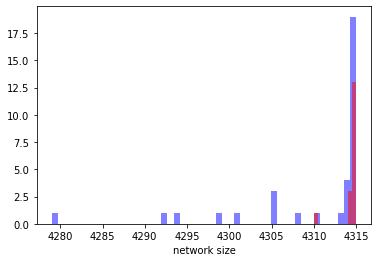

In [115]:
ndot2ns = []
for x in newDogOldTrick:
    ndot2ns.append(x2ns[x])

newO2only2ns = []
for x in newO2only:
    newO2only2ns.append(x2ns[x])

plt.hist(ndot2ns, bins=50, color='b', alpha=0.5)
plt.hist(newO2only2ns, bins=10, color='r', alpha=0.5)
plt.xlabel('network size')

plt.show()

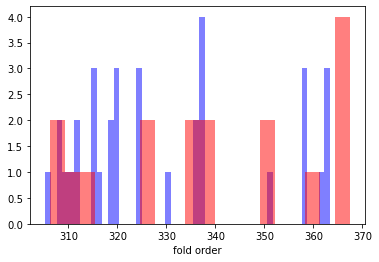

In [116]:
#fo
ndot2fo = []
for x in newDogOldTrick:
    ndot2fo.append(x2foAveNONE[x])

newO2only2fo = []
for x in newO2only:
    newO2only2fo.append(x2foAveNONE[x])

plt.hist(ndot2fo, bins=50, color='b', alpha=0.5)
plt.hist(newO2only2fo, bins=20, color='r', alpha=0.5)
plt.xlabel('fold order')

plt.show()

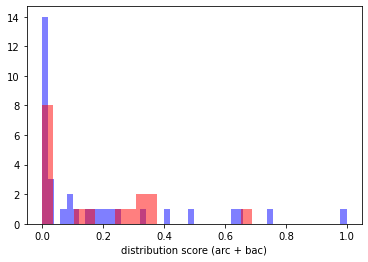

In [117]:
#ds
ndot2ds = []
for x in newDogOldTrick:
    ndot2ds.append(x2ds_ab[x])

newO2only2ds = []
for x in newO2only:
    newO2only2ds.append(x2ds_ab[x])

plt.hist(ndot2ds, bins=50, color='b', alpha=0.5)
plt.hist(newO2only2ds, bins=20, color='r', alpha=0.5)
plt.xlabel('distribution score (arc + bac)')

plt.show()

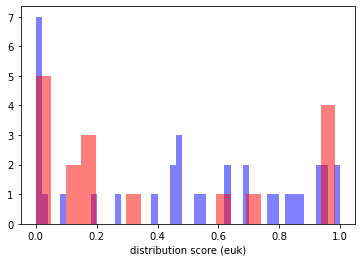

In [118]:
#ds (eukaryotes)
ndot2ds = []
for x in newDogOldTrick:
    ndot2ds.append(xgroup2ds_e[x])

newO2only2ds = []
for x in newO2only:
    newO2only2ds.append(xgroup2ds_e[x])

plt.hist(ndot2ds, bins=50, color='b', alpha=0.5)
plt.hist(newO2only2ds, bins=20, color='r', alpha=0.5)
plt.xlabel('distribution score (euk)')

plt.show()

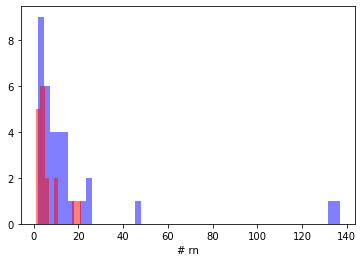

In [119]:
#numrn
ndot2numrn = []
for x in newDogOldTrick:
    ndot2numrn.append(len(x2rn[x]))

newO2only2numrn = []
for x in newO2only:
    newO2only2numrn.append(len(x2rn[x]))

plt.hist(ndot2numrn, bins=50, color='b', alpha=0.5)
plt.hist(newO2only2numrn, bins=10, color='r', alpha=0.5)
plt.xlabel('# rn')

plt.show()

In [120]:
print(len(newDogOldTrick & alpha))
print(len(newDogOldTrick & beta))
print(len(newDogOldTrick & mixed))
print(len(newDogOldTrick & other))

19
6
5
4


In [121]:
print(len(newO2only & alpha))
print(len(newO2only & beta))
print(len(newO2only & mixed))
print(len(newO2only & other))

6
2
7
2


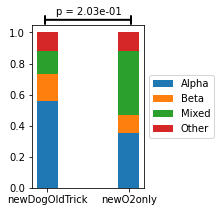

In [122]:
categories = ['newDogOldTrick', 'newO2only']  # 34, 17
alpha_valuesFO = [19/34, 6/17]
beta_valuesFO = [6/34, 2/17]
mixed_valuesFO = [5/34, 7/17]
other_valuesFO = [4/34, 2/17]

x = np.arange(len(categories))  # the label locations
width = 0.25  # the width of the bars
bar_positions = [0, 1]

fig, ax = plt.subplots(figsize=(2, 3))

# Plotting bars
ax.bar(x, alpha_valuesFO, width, label='Alpha')
ax.bar(x, beta_valuesFO, width, bottom=alpha_valuesFO, label='Beta')
ax.bar(x, mixed_valuesFO, width, bottom=np.array(alpha_valuesFO) + np.array(beta_valuesFO), label='Mixed')
ax.bar(x, other_valuesFO, width, bottom=np.array(alpha_valuesFO) + np.array(beta_valuesFO) + np.array(mixed_valuesFO), label='Other')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# chi-square
contingency_table = np.array([[19, 6, 5, 4], [6, 2, 7, 2]])  # 'oldDogNewTrick', 'noO2old'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.505, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 1.03), xytext=(0.9, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# plt.savefig('XXXXXXX.png', bbox_inches='tight')
plt.show()

# closer look at newO2only

In [123]:
print('x ds(Euk) ds(ArcBac)  Module  X-name')
print('------------------------------')
for x in newO2only:
    print(x, round(xgroup2ds_e[x], 3), round(x2ds_ab[x], 3), x2modules.get(x, 'NO MODULE'), 
          x2names.get(x, 'NO X NAME'))

x ds(Euk) ds(ArcBac)  Module  X-name
------------------------------
3994 0.01 0.009 NO MODULE NO X NAME
6174 0.0 0.0 NO MODULE NO X NAME
3456 0.184 0.336 {'M00147', 'M00146', 'M00143', 'M00142', 'M00144', 'M00145'} NO X NAME
603 0.985 0.013 {'M00174', 'M00804', 'M00528'} STAT-like
241 0.985 0.259 NO MODULE Type III secretory system chaperone-like
620 0.148 0.135 NO MODULE NO X NAME
262 0.128 0.004 NO MODULE NO X NAME
4160 0.01 0.34 {'M00622'} NO X NAME
3752 0.01 0.001 NO MODULE NO X NAME
3579 0.163 0.308 {'M00147', 'M00146', 'M00143', 'M00142', 'M00144', 'M00145'} NO X NAME
3843 0.138 0.366 {'M00147', 'M00146', 'M00143', 'M00142', 'M00144', 'M00145'} NO X NAME
3249 0.612 0.01 NO MODULE NO X NAME
557 0.01 0.004 NO MODULE NO X NAME
3115 0.954 0.152 {'M00878'} GP2-like
3281 0.327 0.687 {'M00147', 'M00146', 'M00143', 'M00142', 'M00144', 'M00145'} NO X NAME
228 0.974 0.359 NO MODULE NO X NAME
867 0.714 0.029 {'M00868', 'M00121'} NO X NAME


**bacterial type III secretion system (T3SS)** delivers virulence proteins, called effectors, into eukaryotic cells. T3SS comprises a transmembrane secretion apparatus and a complex network of specialized chaperones that target protein substrates to this secretion apparatus.

**Gycoprotein 2 (GP2)** GPI-anchor protein previously thought to be exclusively expressed by pancreatic acinar cells of most mammals. Recent studies suggest GP2 is specifically expressed in M cells among intestinal epithelial cells, and serves as a transcytotic receptor for mucosal antigens; GPI-anchor protein represents a posttranslational modification of proteins with a glycolipid and is used ubiquitously in eukaryotes and most likely in some Archaea, but not in bacteria

**STAT** proteins are involved in the development and function of the immune system and play a role in maintaining immune tolerance and tumor surveillance.

In [124]:
xx = ['3281', '3456', '3579', '3843']
for x in xx:
    print(f"X{x}: {x2rn[x]}, direct%={len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total'])}, indirect%={len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total'])}")
mods = sorted(['M00144', 'M00146', 'M00143', 'M00142', 'M00147', 'M00145'])
for m in mods:
    print(m, modules[m])
print('------------------')

x = '867'
print(f"X{x}: {x2rn[x]}")
print(f"direct%={round(len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total']), 3)}, indirect%={round(len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total']), 3)}")
mods = sorted(['M00868', 'M00121'])
for m in mods:
    print(m, modules[m])
print('------------------')

x = '603'
print(f"X{x}: {x2rn[x]}, direct%={len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total'])}, indirect%={len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total'])}")
mods = sorted(['M00528', 'M00174', 'M00804'])
for m in mods:
    print(m, modules[m])
print('------------------')    

x = '3115'
print(f"X{x}: {x2rn[x]}, direct%={len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total'])}, indirect%={len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total'])}")
print('M00878', modules['M00878'])
print('------------------') 

x = '4160'
print(f"X{x}: {x2rn[x]}, direct%={len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total'])}, indirect%={len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total'])}")
print('M00622', modules['M00622'])
print('------------------') 

print('=======NO MODULE========')
xx = sorted(['3994', '3249', '241', '6174', '557', '228', '262', '620', '3752'])
for x in xx:
    print(f"X{x}: {x2rn[x]}, direct%={len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total'])}, indirect%={len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total'])}")

X3281: ['R11945', 'R10572', 'R11874', 'R11945_v1', 'R10572_v1', 'R11945_v2'], direct%=0.0, indirect%=1.0
X3456: ['R11945', 'R11874', 'R11945_v1', 'R11945_v2'], direct%=0.0, indirect%=1.0
X3579: ['R11945', 'R11945_v1', 'R11945_v2'], direct%=0.0, indirect%=1.0
X3843: ['R11945', 'R11874', 'R11945_v1', 'R11945_v2'], direct%=0.0, indirect%=1.0
M00142 NADH:ubiquinone oxidoreductase, mitochondria
M00143 NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria
M00144 NADH:quinone oxidoreductase, prokaryotes
M00145 NAD(P)H:quinone oxidoreductase, chloroplasts and cyanobacteria
M00146 NADH dehydrogenase (ubiquinone) 1 alpha subcomplex
M00147 NADH dehydrogenase (ubiquinone) 1 beta subcomplex
------------------
X867: ['R03220', 'R05817', 'R05819', 'R09491', 'R09032', 'R05818', 'R03678', 'R03220_v2', 'R03678_v1', 'R03678_v4', 'R03678_v3', 'R05819_v1', 'R05818_v1', 'R03220_v1', 'R03678_v2', 'R05817_v2', 'R05817_v1']
direct%=0.143, indirect%=0.857
M00121 Heme biosynthesis, plan

In [125]:
print('x direct indirect')
print('------------------')
for x in newO2only:
    print(f"X{x}, {len(x2O2rn[x]['direct'])/len(x2O2rn[x]['total'])}, {len(x2O2rn[x]['indirect'])/len(x2O2rn[x]['total'])}, numrn={len(x2rn[x])}")

x direct indirect
------------------
X3994, 0.0, 1.0, numrn=1
X6174, 1.0, 0.0, numrn=4
X3456, 0.0, 1.0, numrn=4
X603, 1.0, 0.0, numrn=3
X241, 1.0, 0.0, numrn=2
X620, 0.5, 0.5, numrn=4
X262, 1.0, 0.0, numrn=21
X4160, 1.0, 0.0, numrn=2
X3752, 1.0, 0.0, numrn=2
X3579, 0.0, 1.0, numrn=3
X3843, 0.0, 1.0, numrn=4
X3249, 1.0, 0.0, numrn=9
X557, 1.0, 0.0, numrn=10
X3115, 1.0, 0.0, numrn=2
X3281, 0.0, 1.0, numrn=6
X228, 1.0, 0.0, numrn=5
X867, 0.14285714285714285, 0.8571428571428571, numrn=17


In [126]:
for x in newO2only:
    print(x, x2rn[x])

3994 ['R10185']
6174 ['R09572', 'R11594', 'R09572_v1', 'R11594_v1']
3456 ['R11945', 'R11874', 'R11945_v1', 'R11945_v2']
603 ['R00148', 'R09518', 'R00148_v1']
241 ['R00078', 'R00078_v1']
620 ['R11013', 'R03868', 'R11013_v1', 'R03868_v1']
262 ['R11711', 'R11713', 'R11712', 'R00111', 'R00557', 'R00558', 'R11711_v1', 'R00111_v2', 'R11713_v1', 'R11712_v2', 'R11712_v3', 'R00557_v2', 'R00557_v1', 'R00111_v1', 'R11712_v1', 'R11713_v3', 'R00558_v2', 'R00558_v1', 'R11713_v2', 'R11711_v2', 'R11711_v3']
4160 ['R09125', 'R09125_v1']
3752 ['R07598', 'R07598_v1']
3579 ['R11945', 'R11945_v1', 'R11945_v2']
3843 ['R11945', 'R11874', 'R11945_v1', 'R11945_v2']
3249 ['R00111', 'R00557', 'R00558', 'R00111_v2', 'R00557_v2', 'R00557_v1', 'R00111_v1', 'R00558_v2', 'R00558_v1']
557 ['R01632', 'R03550', 'R04280', 'R09272', 'R09565', 'R03550_v1', 'R09565_v1', 'R01632_v1', 'R09272_v1', 'R04280_v1']
3115 ['R09838', 'R09838_v1']
3281 ['R11945', 'R10572', 'R11874', 'R11945_v1', 'R10572_v1', 'R11945_v2']
228 ['R00275'

In [127]:
# 6174 is newO2only & b_only  
print(x2O2rn[x])

{'direct': ['R03220'], 'indirect': ['R05817', 'R05819', 'R09491', 'R09032', 'R05818', 'R03678'], 'total': ['R03220', 'R05817', 'R05819', 'R09491', 'R09032', 'R05818', 'R03678']}


In [128]:
for r in x2rn['6174']:
    url = f'https://rest.kegg.jp/get/{r}'
    response = requests.get(url)

    if response.status_code == 200:
        # Print the content of the response
        print(response.text)
        print('---------------------------------')
    else:
        print(f"Error: {response.status_code}")

ENTRY       R09572                      Reaction
NAME        L-proline,2-oxoglutarate:oxygen oxidoreductase (3-hydroxylating)
DEFINITION  L-Proline + 2-Oxoglutarate + Oxygen <=> cis-3-Hydroxy-L-proline + Succinate + CO2
EQUATION    C00148 + C00026 + C00007 <=> C19706 + C00042 + C00011
RCLASS      RC00661  C00148_C19706
ENZYME      1.14.11.28
BRITE       Enzymatic reactions [BR:br08201]
             1. Oxidoreductase reactions
              1.14  Acting on paired donors, with incorporation or reduction of molecular oxygen
               1.14.11  With 2-oxoglutarate as one donor, and incorporation of one atom of oxygen into each donor
                1.14.11.28
                 R09572  L-Proline + 2-Oxoglutarate + Oxygen <=> cis-3-Hydroxy-L-proline + Succinate + CO2
DBLINKS     RHEA: 20268
///

---------------------------------
ENTRY       R11594                      Reaction
NAME        L-proline,2-oxoglutarate:oxygen oxidoreductase (cis-4-hydroxylating)
DEFINITION  L-Proline + 2-Oxoglu

# separate direct & indirect

(0.3797072589271002, '4.607019e-15')


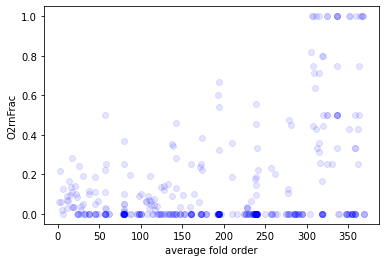

In [129]:
print(pearson(x2foAveNONE, x2O2rnFrac))
scatter(x2foAveNONE, x2O2rnFrac, x_axis='average fold order', y_axis='O2rnFrac')

In [130]:
# x2O2rnFrac = {}
# for x, d in x2O2rn.items():
#     x2O2rnFrac[x] = len((set(d['direct']) | set(d['indirect']))) / len(d['total'])

In [131]:
x2O2rnFracDirect = {}
for x, d in x2O2rn.items():
    x2O2rnFracDirect[x] = len(d['direct']) / len(d['total'])
    
x2O2rnFracIndirect = {}
for x, d in x2O2rn.items():
    x2O2rnFracIndirect[x] = len(d['indirect']) / len(d['total'])

(0.2962935371075688, '1.736515e-09')


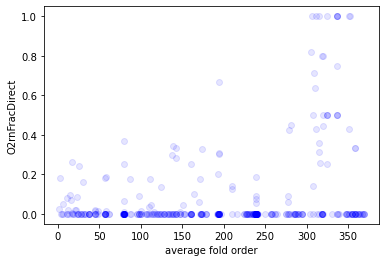

(0.22254995200598943, '7.585603e-06')


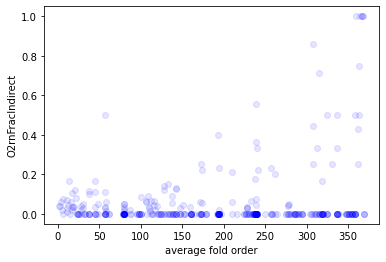

In [132]:
print(pearson(x2foAveNONE, x2O2rnFracDirect))
scatter(x2foAveNONE, x2O2rnFracDirect, x_axis='average fold order', y_axis='O2rnFracDirect')

print(pearson(x2foAveNONE, x2O2rnFracIndirect))
scatter(x2foAveNONE, x2O2rnFracIndirect, x_axis='average fold order', y_axis='O2rnFracIndirect')

In [133]:
withOxyDIRECT = set()
withOxyINDIRECT = set()

for x in x2O2rnFracDirect:
    if x2O2rnFracDirect[x] > 0:
        withOxyDIRECT.add(x)
for x in x2O2rnFracIndirect:
    if x2O2rnFracIndirect[x] > 0:
        withOxyINDIRECT.add(x)

In [134]:
print(withOxyDIRECT)

{'3207', '7574', '6', '7577', '247', '4052', '262', '179', '2002', '244', '633', '302', '881', '146', '2484', '211', '3687', '11', '221', '3777', '3115', '149', '4028', '107', '7514', '2012', '5039', '2003', '150', '131', '209', '604', '205', '243', '1', '4983', '101', '4159', '4160', '2485', '3156', '2004', '3249', '2007', '109', '640', '12', '557', '278', '230', '327', '4294', '304', '10', '241', '620', '281', '257', '187', '4048', '6058', '5038', '603', '108', '5069', '106', '3016', '867', '6174', '4002', '136', '5', '3752', '375', '66', '231', '2486', '4033', '217', '192', '7', '3978', '4110', '914', '331', '228', '223', '325', '601', '4229', '158'}


In [135]:
print(withOxyINDIRECT)

{'9', '7561', '7574', '129', '7524', '7577', '5084', '247', '4052', '236', '179', '3843', '2002', '244', '633', '3456', '2005', '279', '141', '503', '11', '221', '222', '149', '1001', '7578', '107', '3447', '196', '2003', '206', '7567', '3740', '604', '103', '205', '243', '4046', '4952', '1', '298', '101', '4272', '7515', '3994', '2485', '7525', '7579', '2004', '3264', '2007', '109', '3960', '4025', '278', '4011', '7552', '2006', '327', '4019', '316', '210', '7512', '608', '3697', '3281', '2487', '304', '10', '620', '187', '4194', '301', '268', '7510', '6058', '5038', '5069', '4335', '3016', '867', '4002', '5100', '136', '5', '323', '219', '231', '4', '2486', '2011', '4033', '217', '315', '7581', '914', '213', '223', '4024', '602', '6166', '325', '7584', '3579', '218', '371', '7542'}


# color the groups 

# venn diagram of folds

In [136]:
from matplotlib_venn import venn3

In [137]:
len(set(x2ns.keys())), len(withOxyDIRECT), len(withOxyINDIRECT)

(397, 91, 107)

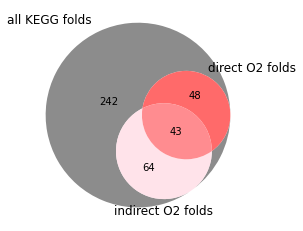

In [138]:
venn3(subsets=[set(x2ns.keys()), withOxyDIRECT, withOxyINDIRECT], set_labels=('all KEGG folds', 'direct O2 folds', 'indirect O2 folds'),
      set_colors=('gray', 'red', 'pink'), alpha=0.9)

# bar chart of folds

In [139]:
# 64: indirect O2
# 43: both direct and indirect O2
# 48: direct O2
# 31: noO2new 
# 210: noO2old

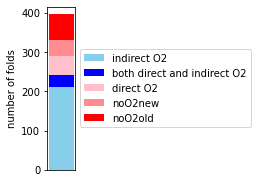

In [140]:
values = [64, 43, 48, 31, 210]
labels = ['indirect O2', 'both direct and indirect O2', 'direct O2', 'noO2new', 'noO2old']
colors = ['red', '#ff8c90', 'pink', 'blue', 'skyblue']

fig, ax = plt.subplots(figsize=(0.5, 3))
width = 0.1

# Plotting bars
ax.bar(0, values[4], width, color=colors[4])
ax.bar(0, values[3], width, bottom=values[4], color=colors[3])
ax.bar(0, values[2], width, bottom=values[3] + values[4], color=colors[2])
ax.bar(0, values[1], width, bottom=values[2] + values[3] + values[4], color=colors[1])
ax.bar(0, values[0], width, bottom=values[1] + values[2] + values[3] + values[4], color=colors[0])

plt.legend(labels, bbox_to_anchor=(1, 0.5), loc='center left')
plt.ylabel('number of folds')
plt.xticks([])
# plt.savefig('newbar.png', dpi=300, bbox_inches='tight')
plt.show()

# O2 and H2O2 timing

In [144]:
set(rns_unreached_wo_O2)

{'R04907',
 'R06475',
 'R08653',
 'R12306',
 'R10357',
 'R06828',
 'R10405',
 'R10361',
 'R07874',
 'R07186',
 'R07446',
 'R08611',
 'R12178',
 'R08164',
 'R07894',
 'R01459',
 'R07897',
 'R03998',
 'R00643',
 'R02715',
 'R03568',
 'R01457',
 'R03246',
 'R01834',
 'R11012',
 'R04886',
 'R03559',
 'R07711',
 'R09786',
 'R08170',
 'R00893',
 'R02534',
 'R06456',
 'R02535',
 'R02609',
 'R02383',
 'R02902',
 'R03954',
 'R07887',
 'R07939',
 'R04328',
 'R03299',
 'R08904',
 'R09713',
 'R10055',
 'R04570',
 'R02859',
 'R10424',
 'R07979',
 'R03439',
 'R09658',
 'R07224',
 'R08835',
 'R05320',
 'R09980',
 'R02477',
 'R10191',
 'R11228',
 'R08899',
 'R10491',
 'R12371',
 'R10572',
 'R11956',
 'R00081',
 'R08141',
 'R02444',
 'R05357',
 'R08203',
 'R07955',
 'R10114',
 'R11277',
 'R06363',
 'R11037',
 'R06803',
 'R08837',
 'R01022',
 'R11097',
 'R07559',
 'R07188',
 'R05405',
 'R03674',
 'R00678',
 'R02078',
 'R06455',
 'R11043',
 'R10989',
 'R09957',
 'R04178',
 'R07575',
 'R07221',
 'R05817',

In [142]:
batm = pd.read_pickle('../2023-09-21_11-42-33_random_fold_ordering_42287-fixed-rn-seeds.pkl')

In [145]:
rnWOoxy = set(batm.scope.rns) - set(rns_unreached_wo_O2)

In [155]:
rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
print(len(rn2eqn_SI))

12277


In [202]:
for key in rn2rules.keys():
    if 'R04248' in key:
        print(key)

In [200]:
H2O2folds  = set()
for rn in rnWOoxy:
    if 'C00027' in rn2eqn_SI[rn]:
        if batm.rns_folditer[rn] < 295:
            print(f"[{batm.rns_folditer[rn]}] {rn}: {rn2eqn_SI[rn]}")
            if rn2rules.get(rn, 0) != 0:
                s = {str(item) for subset in rn2rules[rn] for item in subset}
                H2O2folds = s | H2O2folds
                print(f'     {s}')
            else:
                print(f'      *** not in rn2rules ***')

[170] R00113: C00027 + C00005 + C00080 => 2C00001 + C00006
      *** not in rn2rules ***
[207] R12611_v1: C00082 + C00027 + Z00025 => C00355 + C00001 + Z00025
      *** not in rn2rules ***
[252] R08863_v1: C06452 + C00027 + Z00015 => 2C00001 + C06454 + Z00015
      *** not in rn2rules ***
[170] R11522: 2C00011 + 4C00001 + C00032 => 2C00027 + C21284
     {'304'}
[170] R00602_v1: C00132 + C00027 + Z00025 + C00132 + C00027 + Z00025 + C00132 + C00027 + Z00025 => 2C00001 + C00067 + Z00025 + 2C00001 + C00067 + Z00025 + 2C00001 + C00067 + Z00025
     {'4028', '4048', '2485', '136'}
[171] R09540_v1: 2C00072 + C00027 + Z00025 => 2C01041 + 2C00001 + Z00025
     {'136'}
[170] R09740_v1: C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025
     {'149'}
[170] R04248: C03557 + C00027 => C00189 + C00009
      *** not in rn2rules ***
[170] R12455: 2C00001 + C00032 + C00011 => C22173 + C00027
     {'304'}
[170] R09507_v1: C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010
     {'108

In [194]:
H2O2folds

{'107', '108', '136', '149', '2003', '244', '2485', '304', '4028', '4048'}

In [207]:
# 170 (H2O2) ~ 295 (Oxygen)
for x in H2O2folds:
    print(x, batm.folds_folditer[x], x2O2rnFrac[x])

2003 6 0.128
304 12 0.08854166666666667
136 171 0.23529411764705882
4028 357 0.3333333333333333
2485 91 0.1
108 98 0.09090909090909091
107 221 0.14814814814814814
149 74 0.19701492537313434
4048 357 0.3333333333333333
244 134 0.3515625


In [ ]:
# X136 (fo = 171), X107 (fo = 221) have H2O2 reactions, and come after H2O2 and before O2

In [ ]:
# X136 is recruited for these rxns:
    # R09540 2 Ascorbate + Hydrogen peroxide <=> 2 Monodehydroascorbate + 2 H2O  
    # R00644 Ascorbate + Hydrogen peroxide <=> Dehydroascorbate + 2 H2O  

In [ ]:
# 65 reactions total:
    # 36/65 use H2O2
    # 14/65 use O2

In [ ]:
# X107 is recruited for these rxns:
# R12698 Dihydro-heme d1 + Acceptor <=> Heme d1 + Reduced acceptor